In [41]:
import pickle
from dython.nominal import associations
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
from numpy import load
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score, cross_validate
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import shuffle
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor

In [54]:
with open('X_big.pickle', 'rb') as handle:
    load_X = pickle.load(handle)

with open('Y_big.pickle', 'rb') as handle:
    load_Y = pickle.load(handle)

X = pd.DataFrame(load_X, columns=["i", "i_atom_num", "i_radius", "i_mass", "i_e_negat", "i_hybrid", "j", "j_atom_num", "j_radius", "j_mass", "j_e_negat", "j_hybrid", "R_ij", "bond_order", "1st_nei"])
y = pd.DataFrame(load_Y)

   i  i_atom_num  i_radius  i_mass  i_e_negat  i_hybrid  j  j_atom_num  \
0  C           6        70   12.00       2.55         3  C           6   
1  C           6        70   12.00       2.55         3  C           6   
2  O           8        60   16.00       3.44         1  C           6   
3  H           1        25    1.01       2.20         1  C           6   
4  C           6        70   12.00       2.55         4  H           1   

   j_radius  j_mass  j_e_negat  j_hybrid      R_ij  bond_order      1st_nei  
0        70   12.00       2.55         4  0.151457       0.986  [CCO, CHHH]  
1        70   12.00       2.55         4  0.153065       0.935  [CCO, CCCH]  
2        70   12.00       2.55         3  0.122295       1.864     [C, CCO]  
3        70   12.00       2.55         4  0.109654       0.925    [C, CHHH]  
4        25    1.01       2.20         1  0.109250       0.939    [CHHH, C]  
   i  i_atom_num  i_radius  i_mass  i_e_negat  i_hybrid  j  j_atom_num  \
0  C         

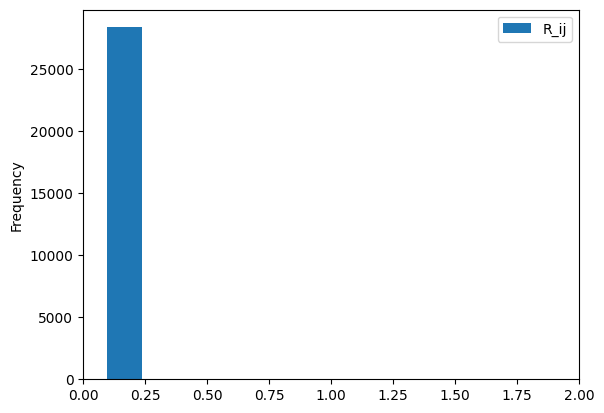

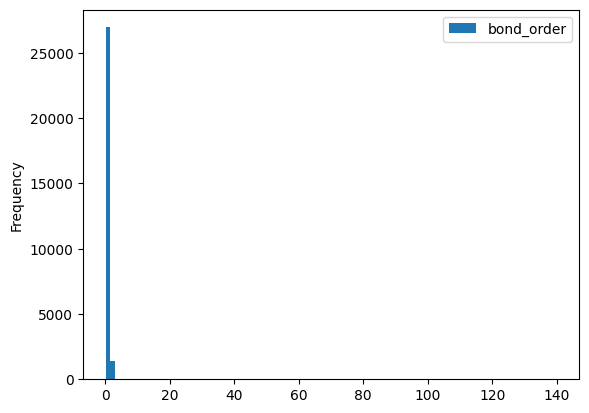

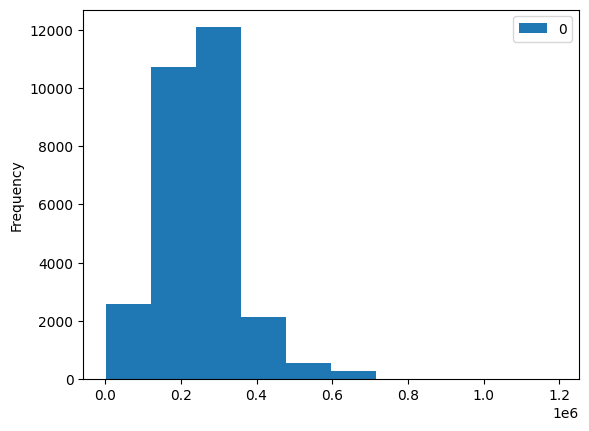

In [55]:
print(X.head())
X.plot.hist(column="R_ij", bins=1000, xlim=(0, 2))
X.plot.hist(column="bond_order", bins=100)
y.plot.hist()

print(X.head())
print(X.tail())

In [56]:
X[["i_nei", "j_nei"]] = X["1st_nei"].tolist()
X.drop(columns="1st_nei", inplace=True)

array(['C', 'O', 'H', 'SI', 'N', 'F', 'P', 'S', 'CL', 'BR', 'I', 'B'],
      dtype=object)

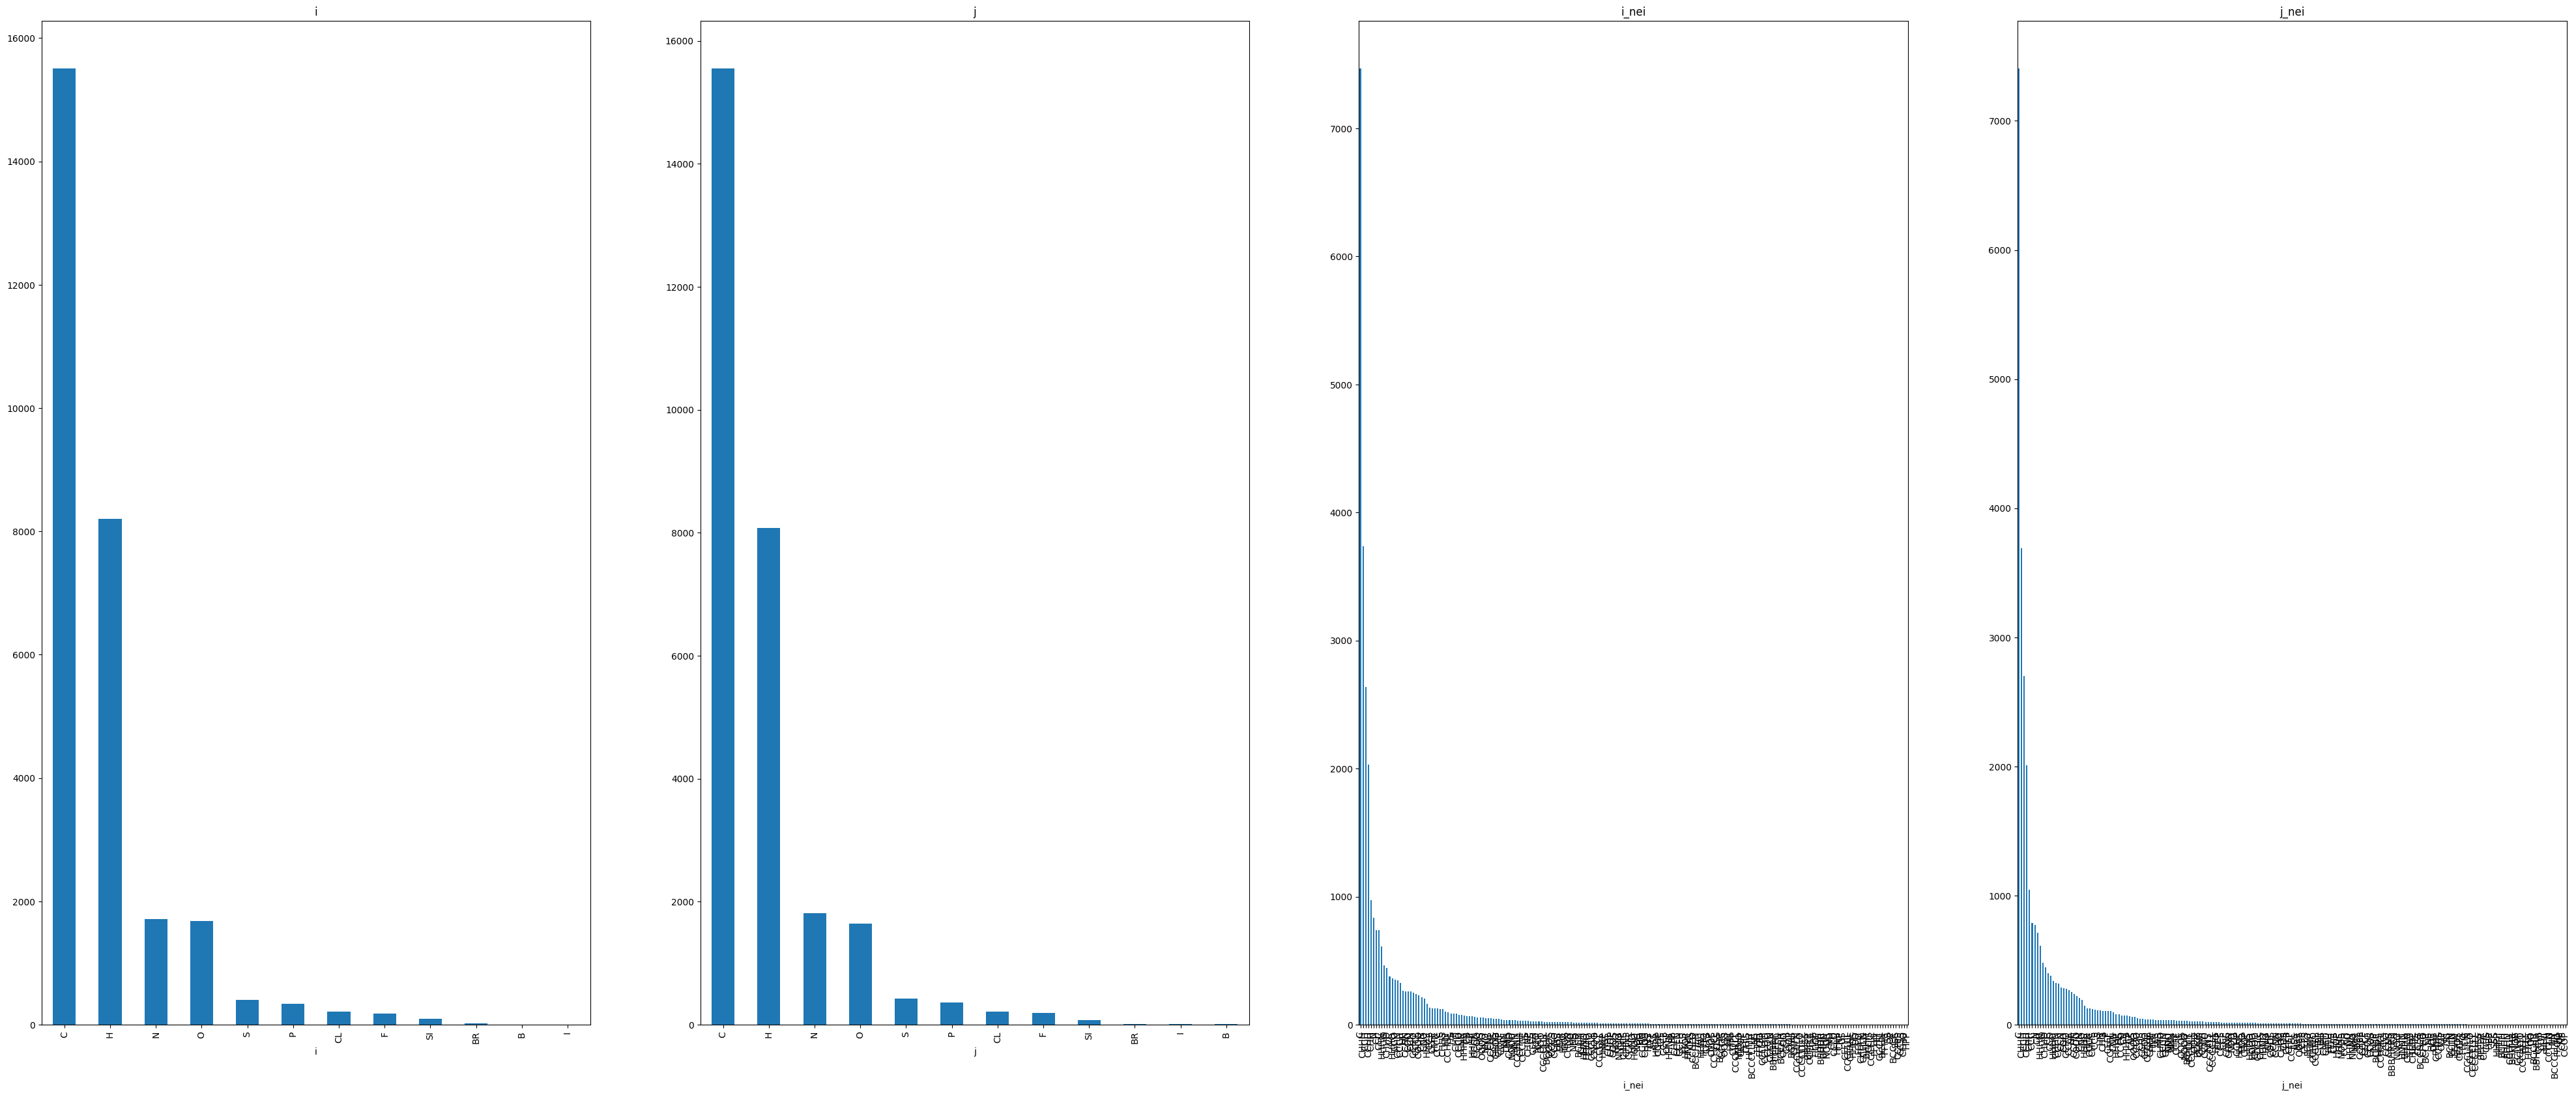

In [57]:
cat_features = ['i', 'j', 'i_nei', 'j_nei']
fig, ax = plt.subplots(1, len(cat_features), figsize=(50,20))

for i, cat_feature in enumerate(X[cat_features]):
    X[cat_feature].value_counts().plot(kind="bar",
                                          title=cat_feature, 
                                          ax=ax[i], )

X['i'].unique()

In [33]:
print(len(sorted(X['i'].unique())))
print(sorted(X['j'].unique()))

11
['BR', 'C', 'CL', 'F', 'H', 'I', 'N', 'O', 'P', 'S', 'SI']


/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:321: RuntimeWarning: Rounded eta = 1.0000000000000004 to 1. This is probably due to floating point precision issues.
  warnings.warn(
/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:321: RuntimeWarning: Rounded eta = 1.0000000000000004 to 1. This is probably due to floating point precision issues.
  warnings.warn(
/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:736: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[i], columns[j]] = _inf_nan_str(ij)
/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:737: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly c

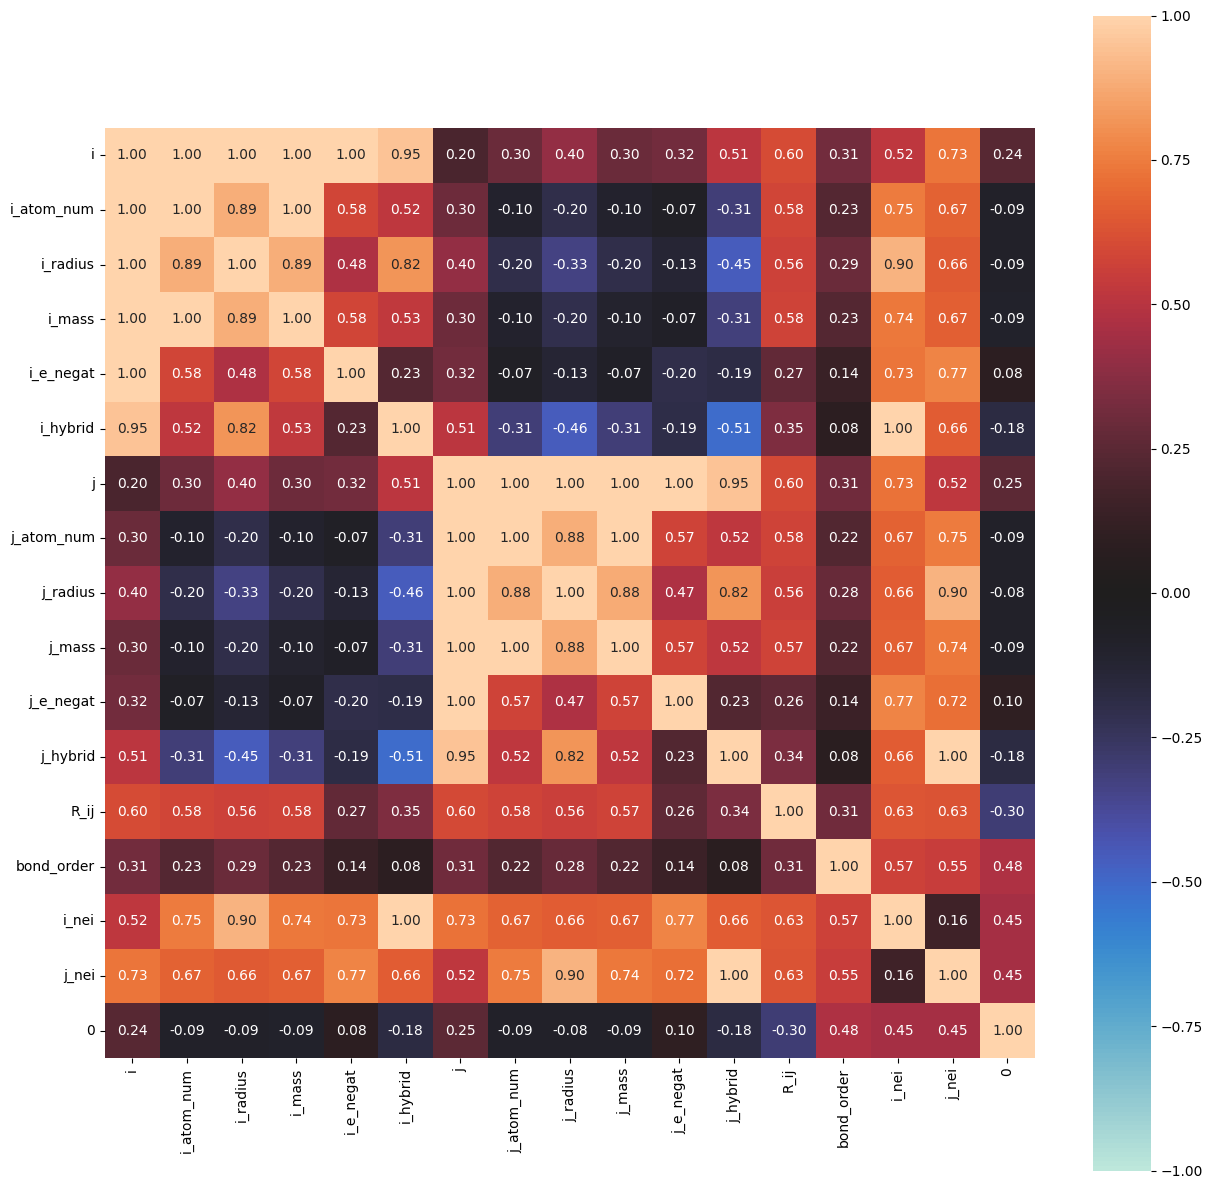

In [65]:
joint=X.join(y)
complete_correlation= associations(joint, figsize=(15,15))

In [66]:
def one_hot_encode_column(df: pd.DataFrame, col: int, pref: str = None) -> pd.DataFrame:
    encoded_column = pd.get_dummies(df[col], prefix=pref)
    df.drop(col, axis=1, inplace=True)
    # try:
    df = df.join(encoded_column)
    # except ValueError as verr:
    #     if "overlap" in verr.__str__():
    #         df = df.merge(encoded_column, left_on="BR", right_on="BR")

    return df

In [67]:
X = one_hot_encode_column(X, "i", "i")
X = one_hot_encode_column(X, "j", "j")
X = one_hot_encode_column(X, "i_nei", "i_nei")
X = one_hot_encode_column(X, "j_nei", "j_nei")


X.columns = X.columns.map(str)


In [68]:
print(X.head())
print(X.index)

   i_atom_num  i_radius  i_mass  i_e_negat  i_hybrid  j_atom_num  j_radius  \
0           6        70   12.00       2.55         3           6        70   
1           6        70   12.00       2.55         3           6        70   
2           8        60   16.00       3.44         1           6        70   
3           1        25    1.01       2.20         1           6        70   
4           6        70   12.00       2.55         4           1        25   

   j_mass  j_e_negat  j_hybrid  ...  j_nei_OOP  j_nei_OOS  j_nei_OOSS  \
0   12.00       2.55         4  ...      False      False       False   
1   12.00       2.55         4  ...      False      False       False   
2   12.00       2.55         3  ...      False      False       False   
3   12.00       2.55         4  ...      False      False       False   
4    1.01       2.20         1  ...      False      False       False   

   j_nei_OP  j_nei_OSS  j_nei_P  j_nei_PP  j_nei_S  j_nei_SS  j_nei_SSS  
0     False      F

<Axes: ylabel='Frequency'>

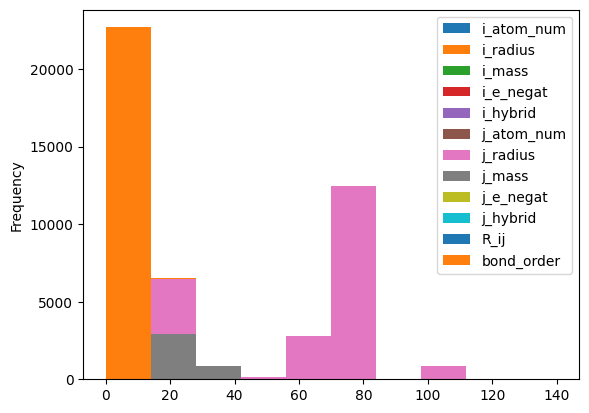

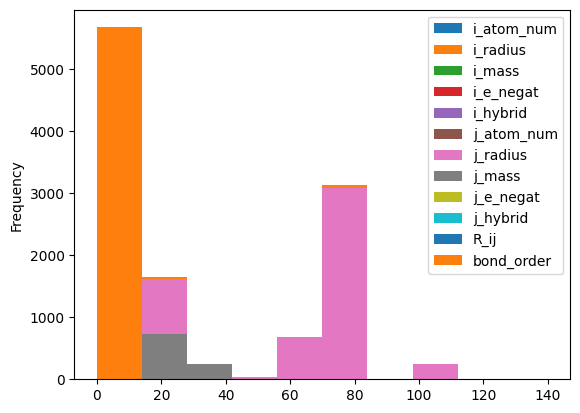

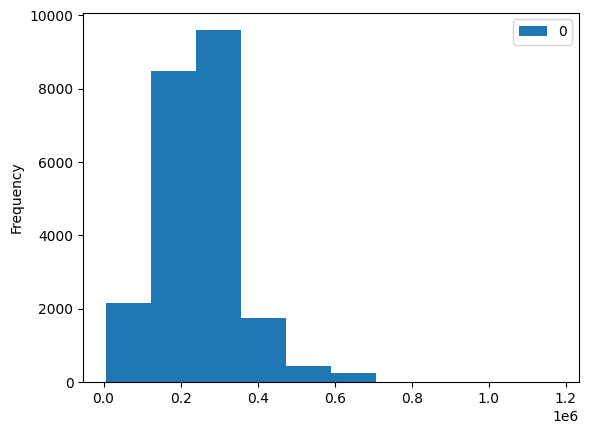

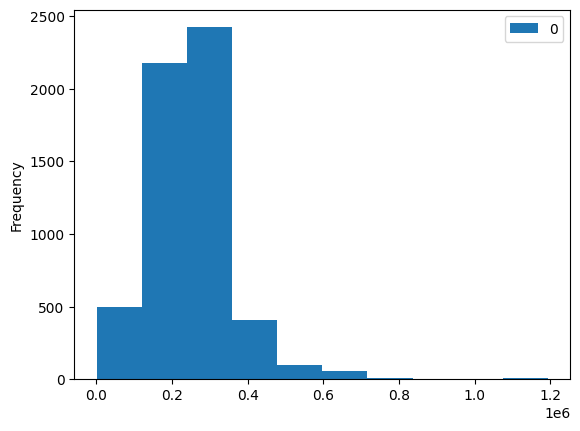

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)
X_train.plot.hist()
X_test.plot.hist()
y_train.plot.hist()
y_test.plot.hist()

In [70]:
X_shuf, y_shuf = shuffle(X, y)
train_sizes = np.linspace(0.1, 1, 50)
train_size_abs, train_scores, test_scores = learning_curve(LinearRegression(), X_shuf, y_shuf, shuffle = True, train_sizes=train_sizes)

[0.63089973 0.62632573 0.62276518 0.61697615 0.61469218 0.61411801
 0.61284716 0.61379712 0.61460033 0.61080879 0.60962245 0.60480698
 0.60492716 0.59814232 0.59621776 0.60185082 0.6005485  0.60020847
 0.59332793 0.60164787 0.6005088  0.59924299 0.59879844 0.59767664
 0.59695467 0.59632582 0.59565356 0.59483943 0.59414601 0.59408074
 0.59473023 0.59495378 0.59549967 0.59546395 0.59455359 0.59445759
 0.59545131 0.59255933 0.58908694 0.59594358 0.59650066 0.59785373
 0.59645598 0.59525022 0.59541964 0.59564574 0.59557901 0.5951734
 0.59535288 0.59543514]
[-2.23636222e+20 -1.27605921e+20 -8.58659075e+19 -7.79852915e+18
 -2.54515887e+19 -1.02657524e+18 -7.20316853e+19 -6.56645548e+18
 -8.10453956e+17 -1.40827795e+18 -5.42222943e+18 -2.30363145e+19
 -1.45847723e+19 -2.55469172e+18 -3.90046197e+18 -3.01386778e+18
 -5.31341685e+18 -9.80885952e+18 -1.21328145e+19 -3.12302328e+17
 -2.05810188e+18 -2.42760364e+16 -6.48144554e+15 -1.07522448e+15
 -4.92898804e+17 -9.09442506e+17 -2.81281067e+14 -7

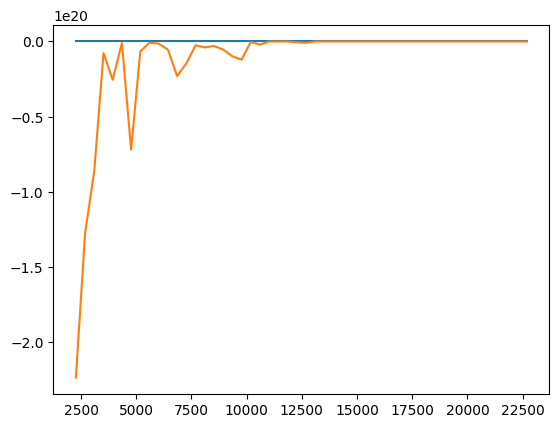

In [73]:
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)
plt.plot(train_size_abs, train_scores_mean)
plt.plot(train_size_abs, test_scores_mean)
print(train_scores_mean)
print(test_scores_mean)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

N = len(X)

#idx = 0

oddities = []
oddities_scores = []
test_scores = []
train_scores = []
test_scores = []
train_size = []
for i in range(5, N, 50):
    X_shuf, y_shuf = shuffle(X, y)
    #print(idx)
    Xnew_train = X_shuf[:i]
    ynew_train = y_shuf[:i]
    Xnew_test = X_shuf[i:]
    ynew_test = y_shuf[i:]
    # print(np.max(ynew_train))
    # ynew_test = y[i:]
    model = LinearRegression()
    reg = model.fit(Xnew_train, ynew_train)
    ytrain_predict = reg.predict(Xnew_train)
    ytest_predict = reg.predict(Xnew_test)
    #score_train = mean_squared_error(ynew_train, ytrain_predict)
    score_train = r2_score(ynew_train, ytrain_predict)
    score_test = r2_score(ynew_test, ytest_predict)

    # train_scores.append(reg.score(Xnew_train, ynew_train))
    # test_scores.append(reg.score(Xnew_test, ynew_test))
    train_scores.append(score_train)
    test_scores.append(score_test)
    train_size.append(i)
    if i > 10000 and score_test < 0:
        oddities.append(Xnew_test)
        oddities_scores.append(score_test)
        
    #Xnew_train.plot.hist(bins=100)
    #Xnew_test.plot.hist(bins=100)
    #ynew_train.plot.hist(bins=50)
    #ynew_test.plot.hist(bins=50)
    #idx += 1


In [74]:
#plt.plot(train_size, train_scores, label="train")
plt.plot(train_size, train_scores, label="test")
plt.legend(loc='best')
plt.show()
#print(len(oddities))
print(test_scores)

#print(oddities[103])
#print(test_scores)
#print(oddities_scores[103])
#oddities[103].plot.hist(bins=100)


NameError: name 'train_size' is not defined

In [79]:
X_shuf, y_shuf = shuffle(X, y)
scores = cross_validate(XGBRegressor(), X_shuf, y_shuf, scoring='r2', cv=40, return_train_score=True)


In [80]:
print(scores["test_score"].mean())
print(scores["train_score"].mean())

0.6701244325890535
0.7184486069350133


In [81]:
train_size_abs, train_scores, test_scores = learning_curve(XGBRegressor(), X, y, shuffle = True, train_sizes=np.linspace(0.1, 1, 20), cv=20)

[0.60637281 0.62545229 0.63583847 0.64248177 0.64364711 0.64932637
 0.65119832 0.65515268 0.65726788 0.65790827 0.6612099  0.66244459
 0.66464488 0.66376518 0.66365823 0.66638395 0.66608004 0.66700202
 0.66848863 0.66768619]
[ 2694  3970  5246  6523  7799  9075 10351 11628 12904 14180 15456 16733
 18009 19285 20561 21838 23114 24390 25666 26943]


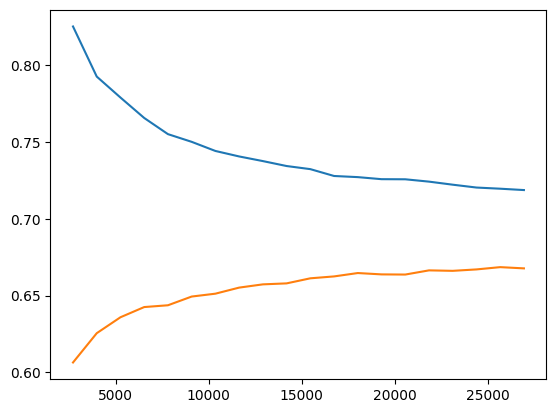

In [82]:
print(test_scores.mean(axis=1))
print(train_size_abs)
plt.plot(train_size_abs,train_scores.mean(axis=1))
plt.plot(train_size_abs, test_scores.mean(axis=1))


In [45]:
print(train_scores)

[[0.94010042 0.93675533 0.92720369 0.92504772 0.94959115 0.92673108
  0.92243346 0.9361213  0.93683341 0.94960365 0.94066918 0.93516148
  0.93163466 0.91443036 0.92472968 0.92618183 0.93136084 0.94331942
  0.92309369 0.93739476]
 [0.90314078 0.91987058 0.90557682 0.89666345 0.90723311 0.92569161
  0.89936828 0.90339192 0.89219881 0.91943863 0.90955688 0.9131603
  0.90222836 0.90002825 0.90062877 0.88558766 0.91529735 0.89407465
  0.8821491  0.92094487]
 [0.8816316  0.90493665 0.86805323 0.87889204 0.90621886 0.88862741
  0.89565921 0.89451323 0.86992274 0.89063475 0.87509216 0.88526835
  0.88326689 0.89638103 0.88203399 0.8782627  0.86860952 0.88825737
  0.86063654 0.90105575]
 [0.86506247 0.89083193 0.87376433 0.8560672  0.87550327 0.8704064
  0.86918621 0.87517057 0.84996509 0.87669626 0.86356901 0.86464583
  0.86826016 0.87029023 0.86451482 0.86102148 0.86450159 0.86085679
  0.84123555 0.89615909]
 [0.86671858 0.87014395 0.86643791 0.84277637 0.87673305 0.85244971
  0.86488804 0.861

In [34]:
rf_train_size_abs, rf_train_scores, rf_test_scores = learning_curve(RandomForestRegressor(), X, y.values.flatten(), shuffle = True, train_sizes=np.linspace(0.1, 1, 20), cv=5)

KeyboardInterrupt: 

In [40]:
scores = cross_validate(RandomForestRegressor(), X_shuf, y_shuf.values.flatten(), scoring='r2', cv=20, return_train_score=True)


In [41]:
print(scores)

{'fit_time': array([16.45559502, 16.3590014 , 16.02556515, 16.08636284, 16.58832693,
       16.21248651, 16.03397703, 16.1254549 , 16.27528334, 16.32744575,
       16.04739928, 16.08081555, 16.09324455, 16.02825308, 16.03075075,
       15.85325956, 16.1027565 , 15.96395302, 15.8802855 , 16.10422325]), 'score_time': array([0.04408646, 0.0448668 , 0.04550409, 0.04409027, 0.04370904,
       0.04391098, 0.04511499, 0.04430962, 0.04478192, 0.04438877,
       0.04420185, 0.04439926, 0.04444551, 0.04414225, 0.04435349,
       0.04512787, 0.04425192, 0.04490089, 0.04455757, 0.0440042 ]), 'test_score': array([0.65514873, 0.64795333, 0.6681648 , 0.55478316, 0.63602563,
       0.63801441, 0.66960679, 0.67003893, 0.68137495, 0.63530808,
       0.68375668, 0.70475319, 0.6969158 , 0.69927286, 0.63928239,
       0.62458503, 0.61082119, 0.65532854, 0.66664941, 0.60950756]), 'train_score': array([0.94943441, 0.94938147, 0.94912941, 0.9498581 , 0.94954764,
       0.94912423, 0.94934063, 0.94878663, 0.94